# 03. Organoid growth chart with PCNtoolkit BLR

Velasco protocol, y = `frac_NPC_IP` (neural progenitor fraction), x = `age` (days in culture).

Plan (TASKS_day1.md, B line):
- **B1** minimal BLR, homoskedastic, B-spline on age -> `results/blr_homo/`
- **B2** heteroskedastic -> `results/blr_hetero/`; + batch effect `publication` -> `results/blr_hetero_batch/`
- **B3** calibration plots

Template: the Oct 2 tutorial notebook (section 4, cell "Model 1: Gaussian BLR").

## Step 1. Check the installed PCNtoolkit and its API

The API changed a lot at version 1.0 (2025), so we print the actual function signatures instead of trusting memory.
The four objects we will use, same as in the tutorial:
- `NormData.from_dataframe(...)`: wraps a pandas DataFrame (which columns are covariates / responses / batch effects).
- `BsplineBasisFunction(...)`: lets the mean curve bend.
- `BLR(...)`: the model template (options: heteroskedastic, fixed_effect, warp_name ...).
- `NormativeModel(template)`: fits, predicts, computes z-scores and centiles.

In [1]:
import sys, inspect
import pcntoolkit
from pcntoolkit import BLR, BsplineBasisFunction, NormData, NormativeModel

print("Python:", sys.version.split()[0], "   executable:", sys.executable)
print("PCNtoolkit:", pcntoolkit.__version__)

# Print messages for every step would be noisy; turn them off (as in the tutorial).
pcntoolkit.util.output.Output.set_show_messages(False)

Python: 3.12.14    executable: /Users/libot/miniconda3/envs/normative/bin/python
PCNtoolkit: 1.3.0


In [2]:
# The actual signatures of the installed version (do not assume an API from memory).
for obj in [NormData.from_dataframe, BsplineBasisFunction.__init__, BLR.__init__, NormativeModel.__init__]:
    print(obj.__qualname__)
    print("   ", inspect.signature(obj), "\n")

print("NormativeModel methods we will use: fit, predict, fit_predict, compute_centiles, compute_zscores, evaluate")
print("Have them all:", all(hasattr(NormativeModel, m) for m in
      ["fit", "predict", "fit_predict", "compute_centiles", "compute_zscores", "evaluate"]))

NormData.from_dataframe
    (name: 'str', dataframe: 'pd.DataFrame', covariates: 'List[str] | None' = None, batch_effects: 'List[str] | None' = None, response_vars: 'List[str | LiteralString] | None' = None, subject_ids: 'str | None' = None, remove_Nan: 'bool' = False, remove_outliers: 'bool' = False, z_threshold: 'float' = 3.0, attrs: 'Mapping[str, Any] | None' = None) -> 'NormData' 

BsplineBasisFunction.__init__
    (self, basis_column: 'int' = 0, degree: 'int' = 3, nknots: 'int' = 5, left_expand: 'float' = 0.05, right_expand: 'float' = 0.05, knot_method: 'str' = 'uniform', knots: 'np.ndarray | list' = None, **kwargs) 

BLR.__init__
    (self, name: 'str' = 'template', fixed_effect: 'bool' = False, fixed_effect_slope: 'bool' = False, fixed_effect_slope_indices: "list[int] | Literal['all']" = None, heteroskedastic: 'bool' = False, fixed_effect_var: 'bool' = False, fixed_effect_var_slope: 'bool' = False, fixed_effect_var_slope_indices: "list[int] | Literal['all']" = None, warp_name: '

## Step 2. Load the data, filter Velasco, merge the fixed train/test split

- `data/hnoca_sample_composition.csv`: 322 samples, one row each.
- Keep the Velasco **protocol** (131 samples). Not the publication "Velasco, 2019" (21 samples).
- `data/split_velasco.csv`: fixed split, 105 train / 26 test, stratified by age bin. Always use it, never refit the split.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("..")                      # notebook lives in notebooks/, repo root is one level up
DATA = ROOT / "data"

df_all = pd.read_csv(DATA / "hnoca_sample_composition.csv")
print("all samples:", df_all.shape)

# Velasco protocol only (the protocol string contains a DOI, so match on the name).
df = df_all[df_all["protocol"].str.contains("Velasco")].copy()
print("Velasco protocol:", df.shape)

# Merge the fixed train/test labels. 'inner' keeps only samples present in both tables.
split = pd.read_csv(DATA / "split_velasco.csv")
df = df.merge(split, on="sample", how="inner")
print("after merge:", df.shape, "   split counts:", df["split"].value_counts().to_dict())

train = df[df["split"] == "train"].reset_index(drop=True)
test = df[df["split"] == "test"].reset_index(drop=True)
assert len(train) == 105 and len(test) == 26, "unexpected split sizes"

cols = ["sample", "age", "publication", "frac_NPC_IP", "split"]
train[cols].head()

all samples: (322, 28)
Velasco protocol: (131, 28)
after merge: (131, 29)    split counts: {'train': 105, 'test': 26}


,sample,age,publication,frac_NPC_IP,split
0,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,70,"Bhaduri, 2020",0.241908,train
1,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,70,"Bhaduri, 2020",0.512422,train
2,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,105,"Bhaduri, 2020",0.195103,train
3,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,168,"Bhaduri, 2020",0.036186,train
4,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,168,"Bhaduri, 2020",0.043568,train


                count  min  max
publication                    
Bhaduri, 2020      17   21  168
Paulsen, 2022      54   28  190
Uzquiano, 2022     39   23  192
Velasco, 2019      21  101  190

count    131.000
mean       0.302
std        0.271
min        0.015
25%        0.080
50%        0.130
75%        0.577
max        0.912
Name: frac_NPC_IP, dtype: float64


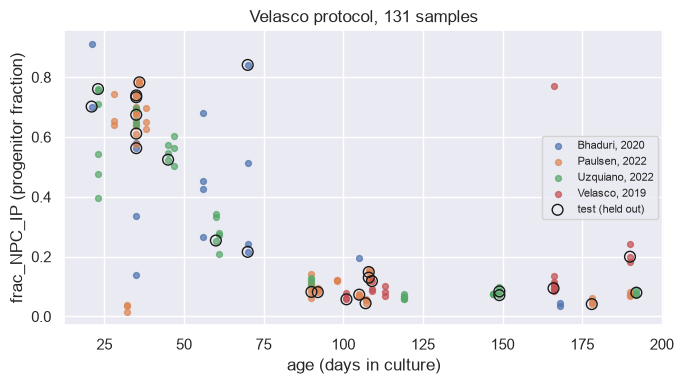

In [4]:
# Quick look: age range per publication, and the y variable.
print(df.groupby("publication")["age"].agg(["count", "min", "max"]))
print()
print(df["frac_NPC_IP"].describe().round(3))

fig, ax = plt.subplots(figsize=(7, 4))
for pub, g in df.groupby("publication"):
    ax.scatter(g["age"], g["frac_NPC_IP"], s=18, alpha=0.7, label=pub)
ax.scatter(test["age"], test["frac_NPC_IP"], s=60, facecolors="none", edgecolors="k", label="test (held out)")
ax.set_xlabel("age (days in culture)")
ax.set_ylabel("frac_NPC_IP (progenitor fraction)")
ax.set_title("Velasco protocol, 131 samples")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step 3. Model 1: homoskedastic BLR with a B-spline on age (`blr_homo`)

Same recipe as the tutorial's "Model 1: Gaussian BLR" cell, with three changes:
`covariates=["age"]`, `response_vars=["frac_NPC_IP"]`, and no batch effects yet.

- `NormData.from_dataframe` wraps a DataFrame. `subject_ids="sample"` keeps the sample id so we can write it to `zscores.csv` later.
- `BsplineBasisFunction(degree=3, nknots=5)`: cubic B-spline, 5 knots. This is what lets the mean curve bend.
- `heteroskedastic=False` (the default): one sigma for all ages. B2 will relax this.
- `fit_predict(train, test)`: fit on train, then predict test. Results are stored *inside* the test NormData:
  `Z` (z-scores), `Yhat` (mu), `centiles` (5, 25, 50, 75, 95 by default), `statistics` (EV, SMSE, MSLL, ...).

Note (PCNtoolkit 1.3.0): `predict` already computes the centiles. Do **not** call `compute_centiles` again afterwards;
in a quick test it left the data in standardized units.

In [5]:
def to_normdata(name, d):
    # Wrap one of our DataFrames into a PCNtoolkit NormData object.
    return NormData.from_dataframe(
        name=name,
        dataframe=d,
        covariates=["age"],              # x: days in culture (expanded with the B-spline below)
        response_vars=["frac_NPC_IP"],   # y: progenitor fraction (one model per response var)
        subject_ids="sample",            # keep the sample id
    )

nd_train = to_normdata("train", train)
nd_test = to_normdata("test", test)
print(nd_train.sizes)

Frozen({'observations': 105, 'response_vars': 1, 'covariates': 1, 'batch_effect_dims': 1})


In [6]:
blr_homo_template = BLR(
    basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),  # bending mean curve
    heteroskedastic=False,                                          # ONE sigma for all ages (B1)
)
blr_homo = NormativeModel(blr_homo_template, savemodel=False, saveresults=False, saveplots=False)

# Fit on train, predict on test. Takes a few seconds.
blr_homo.fit_predict(nd_train, nd_test)

print("What predict stored in nd_test:", list(nd_test.data_vars))
print()
print("test z-scores (first 10):", nd_test.Z.values.ravel()[:10].round(2))
print("test mu (first 10):      ", nd_test.Yhat.values.ravel()[:10].round(3))

What predict stored in nd_test: ['subject_ids', 'Y', 'X', 'batch_effects', 'Z', 'centiles', 'baseline_logp', 'logp', 'Yhat', 'statistics']

test z-scores (first 10): [-0.5   3.37  0.63  0.01 -0.23  0.6   0.19 -0.33 -0.52  0.25]
test mu (first 10):       [0.297 0.297 0.597 0.562 0.132 0.1   0.088 0.109 0.126 0.09 ]


In [7]:
# Built-in test-set evaluation. We only look at a few columns now; B2 step 8 will build our own table.
stats_test = nd_test.get_statistics_df()
stats_test[["EXPV", "SMSE", "MSLL", "Skewness", "Kurtosis"]].round(3)

statistic,EXPV,SMSE,MSLL,Skewness,Kurtosis
response_vars,,,,,
frac_NPC_IP,0.786,0.236,-0.707,2.015,5.855


## Step 4. Export `centiles.csv` and `zscores.csv` (format from CLAUDE.md)

- `centiles.csv`: `age, p5, p25, p50, p75, p95`, one row per day 20..192. We build a grid of fake samples, call `predict`, and read the centiles it computed.
- `zscores.csv`: `sample, age, publication, split, y, mu, sigma, z` for all 131 samples. `predict` gives `Z` and `Yhat` (= mu). PCNtoolkit does not expose sigma directly, so we recover it from the centiles: `sigma = (p95 - p50) / 1.645` (for a Gaussian, the 95th centile is mu + 1.645 sigma).

Wrapped in one function so the B2 models can reuse it.

In [8]:
from scipy import stats
import warnings

Z95 = stats.norm.ppf(0.95)   # 1.645
AGE_GRID = np.arange(20, 193)

def export_results(model, df_all, model_name):
    """Predict on an age grid and on all samples; write results/<model_name>/{centiles,zscores}.csv."""
    out = ROOT / "results" / model_name
    out.mkdir(parents=True, exist_ok=True)

    # 1. Centiles on the age grid. The y column is a dummy: predict needs it to exist, its values are not used for centiles.
    grid = pd.DataFrame({"sample": [f"grid_{a}" for a in AGE_GRID], "age": AGE_GRID, "frac_NPC_IP": 0.0})
    nd_grid = to_normdata("grid", grid)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # the dummy y column triggers harmless divide-by-zero warnings
        model.predict(nd_grid)
    c = nd_grid.centiles.values[:, :, 0]            # shape (5 centiles, 173 ages)
    centiles = pd.DataFrame({"age": AGE_GRID, "p5": c[0], "p25": c[1], "p50": c[2], "p75": c[3], "p95": c[4]})
    centiles.to_csv(out / "centiles.csv", index=False)

    # 2. z-scores for all samples (train and test).
    nd_all = to_normdata("all", df_all)
    model.predict(nd_all)
    c_all = nd_all.centiles.values[:, :, 0]
    zscores = pd.DataFrame({
        "sample": df_all["sample"].values,
        "age": df_all["age"].values,
        "publication": df_all["publication"].values,
        "split": df_all["split"].values,
        "y": df_all["frac_NPC_IP"].values,
        "mu": nd_all.Yhat.values.ravel(),
        "sigma": (c_all[4] - c_all[2]) / Z95,
        "z": nd_all.Z.values.ravel(),
    })
    zscores.to_csv(out / "zscores.csv", index=False)
    return centiles, zscores

centiles_homo, zscores_homo = export_results(blr_homo, df, "blr_homo")
print("written:", sorted(p.name for p in (ROOT / "results" / "blr_homo").iterdir()))

written: ['centiles.csv', 'zscores.csv']


In [9]:
# Sanity checks.
print(centiles_homo.iloc[[0, 30, 80, 172]].round(3))          # days 20, 50, 100, 192
print()
print("sigma range over the grid:", round(zscores_homo["sigma"].min(), 3), "to", round(zscores_homo["sigma"].max(), 3))
print("days with p5 < 0:", int((centiles_homo["p5"] < 0).sum()), "of", len(centiles_homo))
print()
# z recomputed by hand must match PCNtoolkit's z (checks that sigma recovered from centiles is the right one).
z_hand = (zscores_homo["y"] - zscores_homo["mu"]) / zscores_homo["sigma"]
print("max |z_hand - z_pcn|:", float(np.abs(z_hand - zscores_homo["z"]).max()))
print()
print(zscores_homo.groupby("split")["z"].agg(["count", "mean", "std"]).round(3))

     age     p5    p25    p50    p75    p95
0     20  0.320  0.483  0.597  0.710  0.873
30    50  0.197  0.352  0.460  0.569  0.724
80   100 -0.150  0.005  0.113  0.221  0.376
172  192 -0.182 -0.019  0.094  0.207  0.369

sigma range over the grid: 0.16 to 0.167
days with p5 < 0: 118 of 173

max |z_hand - z_pcn|: 1.3322676295501878e-15

       count   mean    std
split                     
test      26  0.267  0.858
train    105  0.001  0.942


## Step 5. Plot the growth chart: `figures/blr_homo_velasco.png`

Scatter of all 131 samples (colour = publication, fixed colour-blind-safe order), five centile lines from `centiles.csv`,
test samples ringed in black. Written as a function so the B2 models reuse it.

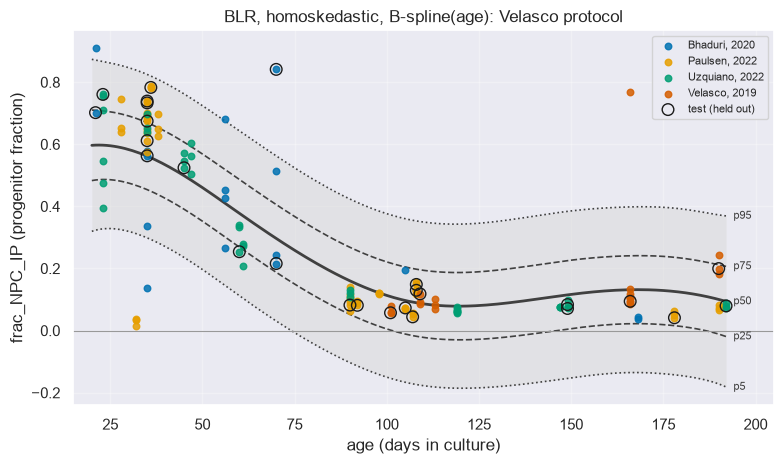

In [10]:
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

# Fixed colour per publication (Okabe-Ito palette, colour-blind safe). Same colour in every figure.
PUB_COLORS = {"Bhaduri, 2020": "#0072B2", "Paulsen, 2022": "#E69F00",
              "Uzquiano, 2022": "#009E73", "Velasco, 2019": "#D55E00"}

def plot_chart(centiles, zscores, title, path, ax=None):
    """Growth chart: centile lines + scatter of all samples, test samples ringed."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4.8))
    # Centile band (5 to 95) and lines.
    ax.fill_between(centiles["age"], centiles["p5"], centiles["p95"], color="0.85", alpha=0.5, lw=0)
    for col, ls, lw in [("p5", ":", 1.2), ("p25", "--", 1.2), ("p50", "-", 2), ("p75", "--", 1.2), ("p95", ":", 1.2)]:
        ax.plot(centiles["age"], centiles[col], color="0.25", ls=ls, lw=lw)
        ax.text(centiles["age"].iloc[-1] + 2, centiles[col].iloc[-1], col, va="center", fontsize=8, color="0.25")
    # Samples, coloured by publication.
    for pub, g in zscores.groupby("publication"):
        ax.scatter(g["age"], g["y"], s=22, color=PUB_COLORS[pub], alpha=0.85, label=pub, zorder=3)
    t = zscores[zscores["split"] == "test"]
    ax.scatter(t["age"], t["y"], s=70, facecolors="none", edgecolors="k", lw=1, label="test (held out)", zorder=4)
    ax.axhline(0, color="0.6", lw=0.8)          # fractions cannot go below 0
    ax.set_xlabel("age (days in culture)")
    ax.set_ylabel("frac_NPC_IP (progenitor fraction)")
    ax.set_title(title)
    ax.set_xlim(15, 205)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")
    if path is not None:
        plt.tight_layout()
        plt.savefig(path, dpi=150)
    return ax

plot_chart(centiles_homo, zscores_homo, "BLR, homoskedastic, B-spline(age): Velasco protocol",
           FIG / "blr_homo_velasco.png")
plt.show()

## Step 6. Model 2: heteroskedastic BLR (`blr_hetero`)

`heteroskedastic=True` lets sigma depend on age. PCNtoolkit models **log(sigma)** as a linear combination of a basis on age,
chosen with `basis_function_var`. The default basis is linear in age (sigma rises or falls monotonically, on a log scale).

We tried three variance bases on this data (test-set MSLL, more negative is better):

| `basis_function_var` | sigma at day 30 | day 100 | day 180 | MSLL | note |
|---|---|---|---|---|---|
| default (linear in age) | 0.19 | 0.14 | 0.11 | -0.78 | stable, monotone |
| `BsplineBasisFunction(nknots=5)` | 0.24 | 0.04 | 0.40 | -0.77 | captures the day-100 minimum, but blows up after day 150 (sparse data + one outlier at 0.77) |
| `PolynomialBasisFunction(degree=2)` | 0.27 | 0.05 | 0.23 | -0.03 | blows up at the edges |

Decision: use the **default linear variance basis** for `blr_hetero`. Simplest thing that runs, best MSLL, stable.
Corner cut: it cannot capture the slight widening after day 150. Revisit after the warp (day 2).

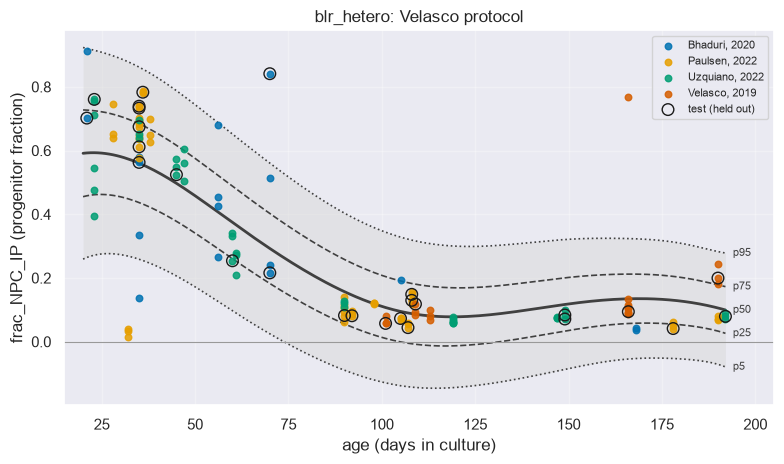

In [11]:
def fit_blr(template, name):
    """Fit a BLR template on train, predict test, export CSVs and figure. Returns (model, centiles, zscores, test NormData)."""
    model = NormativeModel(template, savemodel=False, saveresults=False, saveplots=False)
    nd_tr, nd_te = to_normdata("train", train), to_normdata("test", test)   # fresh copies for each model
    model.fit_predict(nd_tr, nd_te)
    centiles, zscores = export_results(model, df, name)
    plot_chart(centiles, zscores, f"{name}: Velasco protocol", FIG / f"{name}_velasco.png")
    plt.show()
    return model, centiles, zscores, nd_te

blr_hetero_template = BLR(
    basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),  # same bending mean curve
    heteroskedastic=True,                                           # NEW: sigma depends on age
    # basis_function_var left at its default: log(sigma) linear in age
)
blr_hetero, centiles_hetero, zscores_hetero, nd_test_hetero = fit_blr(blr_hetero_template, "blr_hetero")

In [12]:
# Compare sigma(age) and the test statistics of the two models so far.
sig = pd.DataFrame({"age": AGE_GRID,
                    "sigma_homo": (centiles_homo["p95"] - centiles_homo["p50"]) / Z95,
                    "sigma_hetero": (centiles_hetero["p95"] - centiles_hetero["p50"]) / Z95})
print(sig.iloc[[10, 40, 80, 120, 160]].round(3))      # days 30, 60, 100, 140, 180
print()
print("days with p5 < 0:  homo", int((centiles_homo["p5"] < 0).sum()), "  hetero", int((centiles_hetero["p5"] < 0).sum()))
print()
pd.concat({"blr_homo": nd_test.get_statistics_df(), "blr_hetero": nd_test_hetero.get_statistics_df()}
          )[["EXPV", "SMSE", "MSLL", "Skewness", "Kurtosis"]].round(3)

     age  sigma_homo  sigma_hetero
10    30       0.160         0.187
40    60       0.161         0.169
80   100       0.160         0.144
120  140       0.163         0.128
160  180       0.163         0.110

days with p5 < 0:  homo 118   hetero 119



,statistic,EXPV,SMSE,MSLL,Skewness,Kurtosis
,response_vars,,,,,
blr_homo,frac_NPC_IP,0.786,0.236,-0.707,2.015,5.855
blr_hetero,frac_NPC_IP,0.784,0.239,-0.782,2.018,6.191
